This tutorial can be downloaded [link](https://github.com/west-code-development/West/raw/master/Doc/tutorials/advanced/advanced_004.ipynb).

# Advanced Tutorial 4: Analyzing Multiple Roots of the Quasiparticle (QP) Equation

In the $G_0W_0$ method, the quasiparticle (QP) equation

\begin{equation}
E - \varepsilon_{\mathrm{KS}} = \langle \mathrm{Re}\Sigma(E) - V_{\mathrm{xc}} \rangle
\end{equation}

is solved with and without linearization to obtain the QP corrections $E$, where $\varepsilon_{\mathrm{KS}}$ is the Kohn-Sham energy, $\mathrm{Re}\Sigma$ is the real part of the self-energy, and $V_{\mathrm{xc}}$ is the exchange-correlation potential. [Basic Tutorial 2](https://west-code.org/doc/West/latest/tutorials/basic/basic_002.html) demonstrates how to plot the frequency dependence of the self-energy and solve the QP equation graphically by finding the intersections of both sides of the equation.

In some cases, the QP equation may have multiple roots due to the complex frequency dependence of the self-energy. One common approach to select among these roots is to choose the one with the largest spectral function, defined as

\begin{equation}
A(E) = \frac{2 |\mathrm{Im}\Sigma(E)|}{\sigma^2 + |\mathrm{Im}\Sigma(E)|^2}
\end{equation}

where $\mathrm{Im}\Sigma$ is the imaginary part of the self-energy, and $\sigma = E - \varepsilon_{\mathrm{KS}} - \mathrm{Re}\Sigma(E)$. More details can be found in [Scherpelz et al., J. Chem. Theory Comput. 12, 3523 (2016)](https://doi.org/10.1021/acs.jctc.6b00114).

In this tutorial, we examine an example system for which the QP equation exhibits multiple roots. We download the following files:

In [1]:
%%bash
wget -N -q https://west-code.org/doc/training/CuF/pw.in
wget -N -q https://west-code.org/doc/training/CuF/wstat.in
wget -N -q https://west-code.org/doc/training/CuF/wfreq.in
wget -N -q http://www.quantum-simulation.org/potentials/sg15_oncv/upf/F_ONCV_PBE-1.2.upf
wget -N -q http://www.quantum-simulation.org/potentials/sg15_oncv/upf/Cu_ONCV_PBE-1.2.upf

Let's inspect the `pw.in`, `wstat.in`, and `wfreq.in` files, input for `pw.x`, `wstat.x`, and `wfreq.x`, respectively.

In [3]:
%%bash
cat pw.in

&control
calculation  = 'scf'
restart_mode = 'from_scratch'
pseudo_dir   = './'
outdir       = './'
prefix       = 'cuf'
/
&system
ibrav           = 1
celldm(1)       = 20
nat             = 2
ntyp            = 2
ecutwfc         = 50.0
nbnd            = 20
assume_isolated = 'mp'
/
&electrons
diago_full_acc = .TRUE.
/
ATOMIC_SPECIES
Cu 63.546  Cu_ONCV_PBE-1.2.upf
F  18.9984  F_ONCV_PBE-1.2.upf
ATOMIC_POSITIONS angstrom
Cu 0.000000 0.000000 0.000000
F  1.746786 0.000000 0.000000
K_POINTS gamma


In [5]:
%%bash
cat wstat.in

input_west:
  qe_prefix: cuf
  west_prefix: cuf
  outdir: ./

wstat_control:
  wstat_calculation: S
  n_pdep_eigen: 100


In [7]:
%%bash
cat wfreq.in

input_west:
  qe_prefix: cuf
  west_prefix: cuf
  outdir: ./

wstat_control:
  wstat_calculation: S
  n_pdep_eigen: 100

wfreq_control:
  wfreq_calculation: XWGQP
  macropol_calculation: N
  n_pdep_eigen_to_use: 100
  qp_bandrange: [12,13]


We run `pw.x`, `wstat.x`, and `wfreq.x` on 2 cores.

In [ ]:
%%bash
mpirun -n 2 pw.x -i pw.in > pw.out
mpirun -n 2 wstat.x -i wstat.in > wstat.out
mpirun -n 2 wfreq.x -i wfreq.in > wfreq.out

The output file `wfreq.out` contains information about the GW calculation, and the corrected electronic structure can be found in the file `<west_prefix>.wfreq.save/wfreq.json`.

If the reader does NOT have the computational resources to run the calculation, the WEST output file needed for the next step can be directly downloaded as:

In [9]:
%%bash
mkdir -p cuf.wfreq.save
wget -N -q https://west-code.org/doc/training/CuF/wfreq.json -O cuf.wfreq.save/wfreq.json

We load and plot the frequency-dependent QP correction and spectral function for the highest occupied molecular orbital (HOMO).

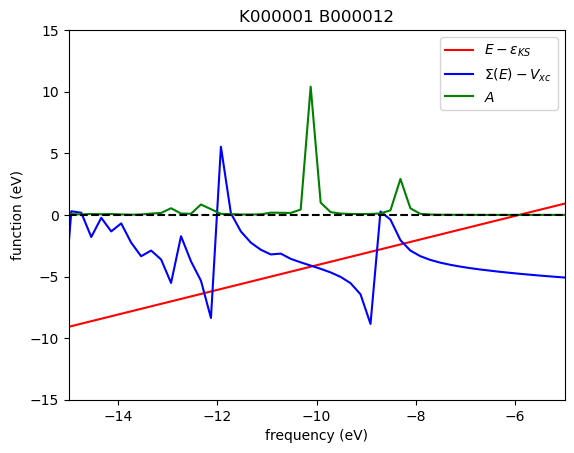

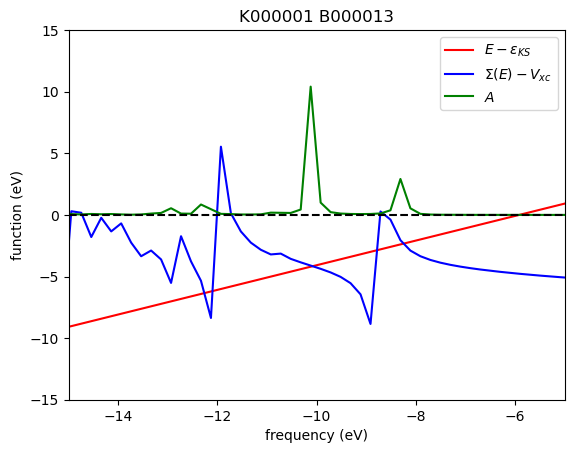

In [11]:
import json
import numpy as np

# Load the output data
with open('cuf.wfreq.save/wfreq.json') as json_file :
    data = json.load(json_file)

# Extract converged quasiparticle (QP) corrections
k = 1
kindex = f'K{k:06d}'

qp_bands = data['input']['wfreq_control']['qp_bands'][0]
eqp = data['output']['Q'][kindex]

freqlist = np.array(data['output']['P']['freqlist'], dtype='f8')
spf = data['output']['P'][kindex]

# Plot
import matplotlib.pyplot as plt

for i, b in enumerate(qp_bands) :

    eks, sigmax, vxcl, vxcnl, eqpSec = eqp['eks'][i], eqp['sigmax'][i], eqp['vxcl'][i], eqp['vxcnl'][i], eqp['eqpSec'][i]

    bindex = f'B{b:06d}'
    sigmac = np.array(spf[bindex]['sigmac']['re'], dtype='f8')
    spectralf = np.array(spf[bindex]['spectralf'], dtype='f8')

    # Left-hand side of QP equation
    plt.plot(freqlist,freqlist-eks,'r-',label=r'$E-\varepsilon_{KS}$')

    # Right-hand side of QP equation without linearization
    plt.plot(freqlist,sigmac+sigmax-vxcl-vxcnl,'b-',label=r'$\Sigma(E)-V_{xc}$')

    # Spectral function
    plt.plot(freqlist,spectralf,'g-',label=r'$A$')

    plt.legend()
    plt.title(kindex+" "+bindex)
    plt.xlabel('frequency (eV)')
    plt.ylabel('function (eV)')
    xmin, xmax = -15, -5
    ymin, ymax = -15, 15
    plt.hlines(xmin=xmin, xmax=xmax, y=0, ls='--', color='k')
    plt.xlim([xmin, xmax])
    plt.ylim([ymin, ymax])
    plt.show()

In the plots above, the red, blue, and green solid lines represent $E - \varepsilon_{\mathrm{KS}}$, $\mathrm{Re}\Sigma(E) - V_{\mathrm{XC}}$, and $A$, respectively. Each intersection of the red and blue lines corresponds to a solution of the QP equation without linearization of the frequency dependency. In this particular case, five roots are found within the energy range of [−15, 5] eV. The solution corresponding to the largest spectral function is located around −10.1 eV.

The WEST code employs the secant root-finding method to solve the QP equation. When multiple roots are present, the secant solver may struggle to converge, often exhibiting behavior where the estimated solution oscillates between several roots. In such cases, visualizing the frequency dependence of the self-energy along with the spectral function, as demonstrated in this tutorial, can help identify the physical root.